In [1]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit import ControlledGate
import math
import random

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 77.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 93.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=4950c4c48ef63495d3bdf2b0a7996b0068b459f8a6330a073fbdfa966c27319b
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


--- BB84 Protocol Simulation WITH Attacker ---
Alice's bits:  [0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0]
Alice's bases: ['d', 'd', 'd', 'd', 'd', 'd', 's', 's', 's', 's', 's', 's']
Eve's bases:   ['d', 's', 'd', 'd', 's', 'd', 's', 'd', 's', 'd', 's', 's']
Bob's bases:   ['s', 'd', 'd', 's', 'd', 'd', 'd', 's', 'd', 'd', 's', 's']
--------------------------------------------------
Alice's sifted key: [1, 1, 0, 1, 0, 1, 0]
Bob's sifted key:   [0, 1, 1, 1, 1, 1, 0]
--------------------------------------------------
Total bits matching in basis: 7
Errors detected: 3
Error Rate: 42.86%

[!] HIGH ERROR RATE DETECTED. Eavesdropper presence confirmed!
    The protocol is aborted. The key will NOT be used.


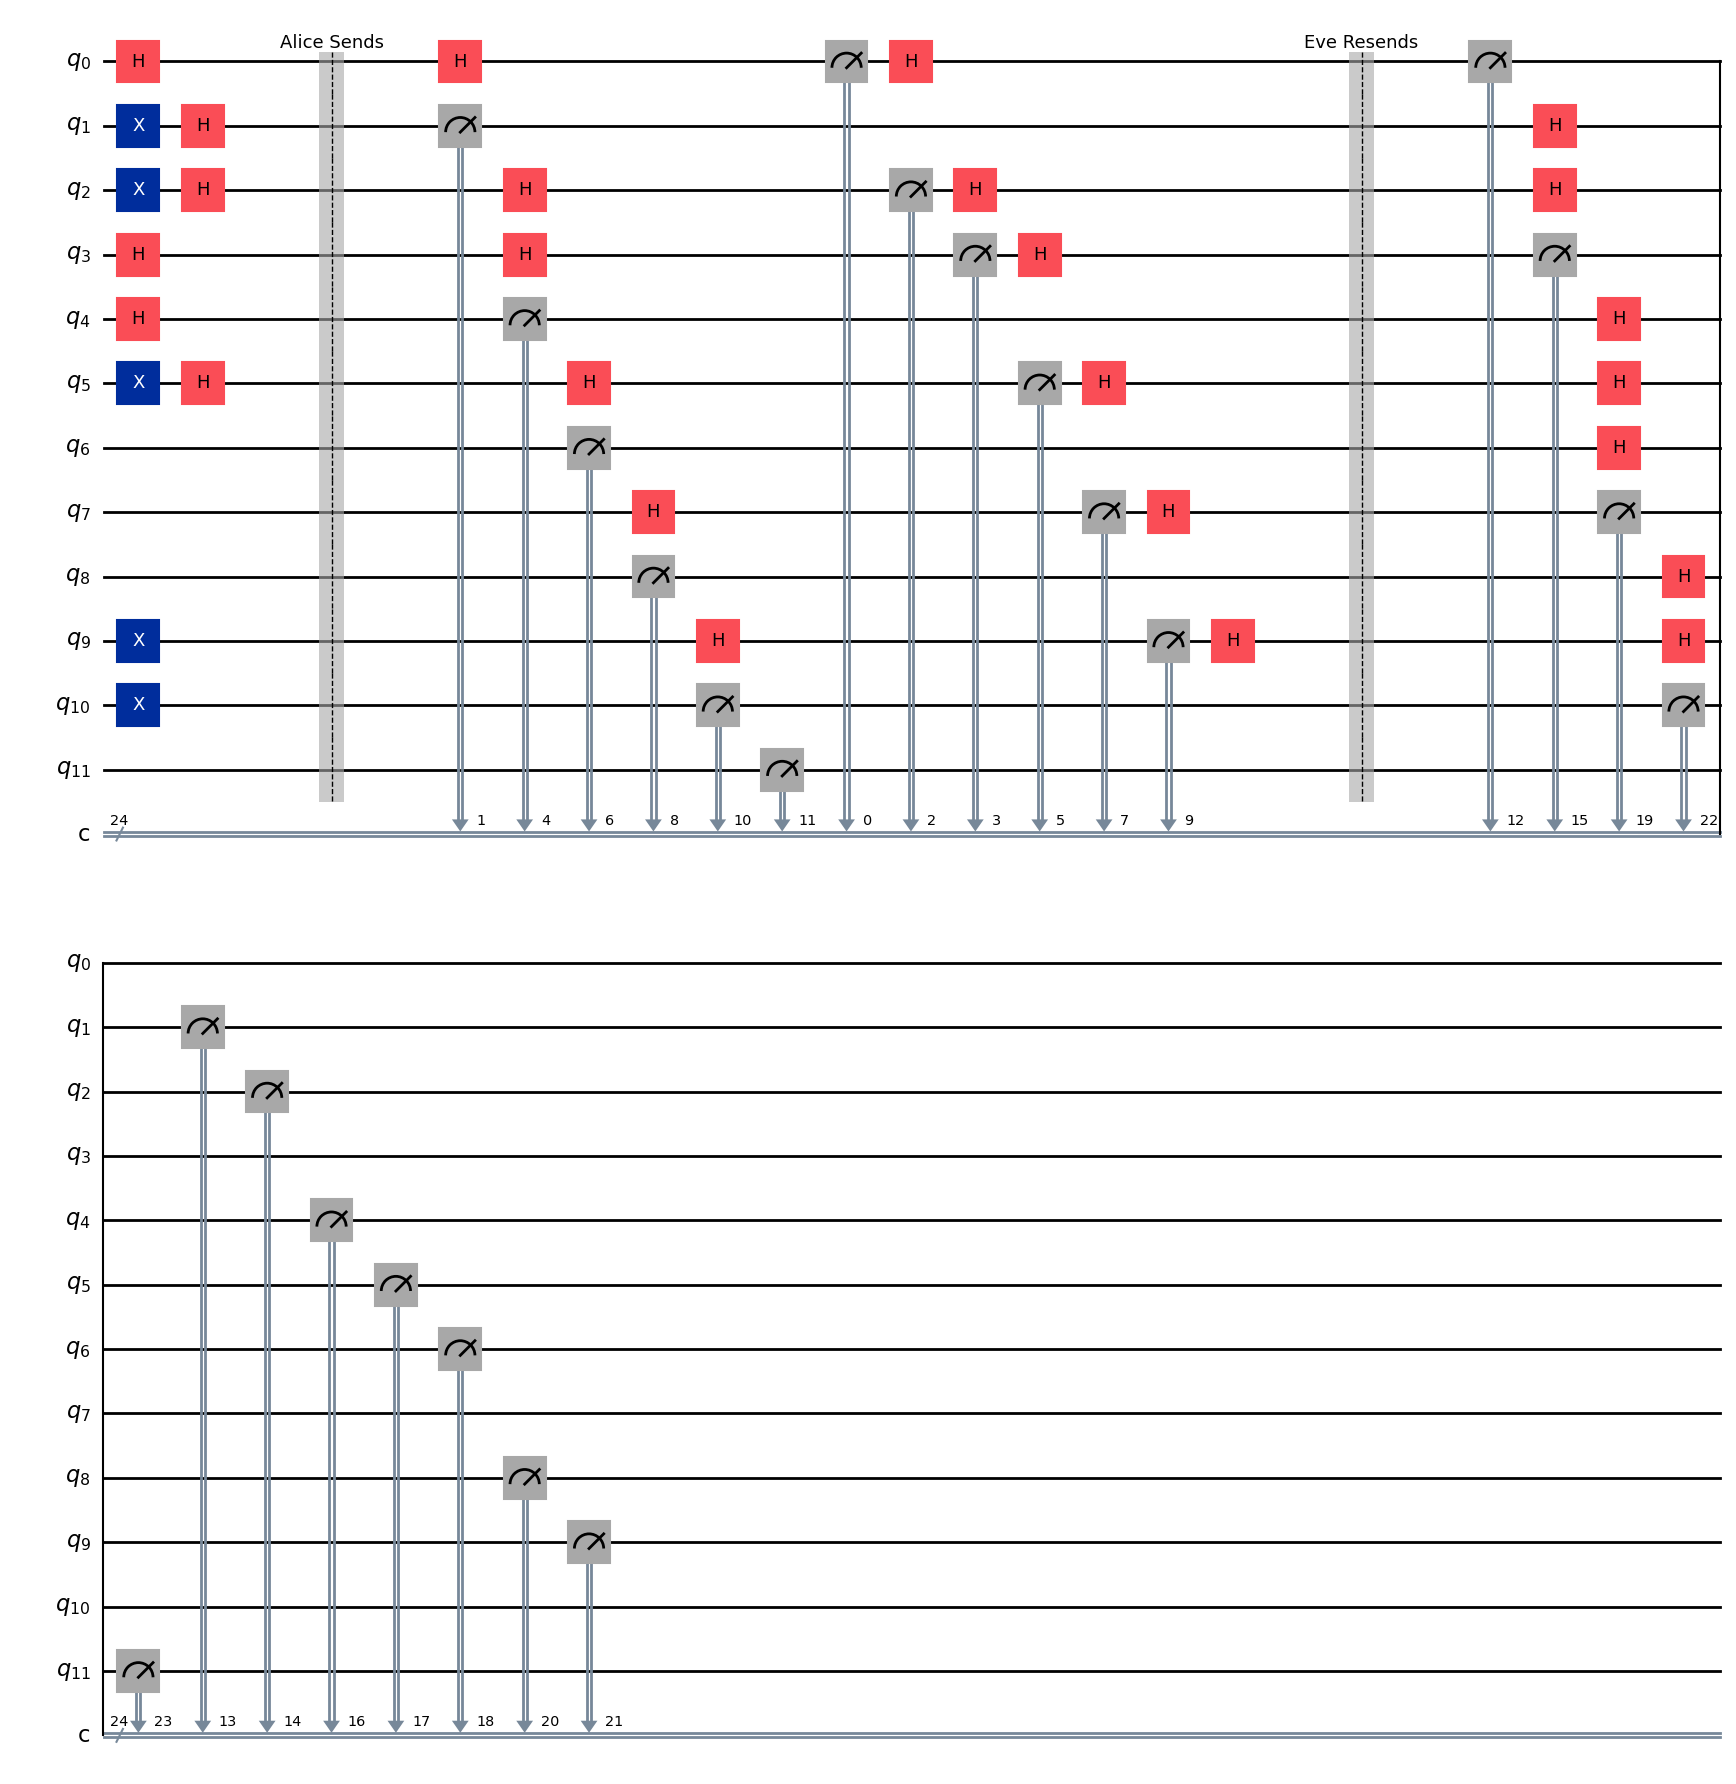

In [2]:
# The aim of the assignment is to simulate the BB84 key distribution protocol.

# This notebook is for a simulation of the protocol with an attacker, to demonstrate that the attacker can be detected.

# Define the number of qubits to send
n = 12

# 1. Alice generates random bits and chooses random bases
alice_bits = [random.randint(0, 1) for _ in range(n)]
alice_bases = [random.choice(['s', 'd']) for _ in range(n)]

# 2. Eve intercepts the qubits and chooses her own random bases to measure them
eve_bases = [random.choice(['s', 'd']) for _ in range(n)]

# 3. Bob receives the intercepted qubits and chooses random bases
bob_bases = [random.choice(['s', 'd']) for _ in range(n)]

# Create a quantum circuit with n qubits and 2*n classical bits
# We need n classical bits for Eve's measurements, and n for Bob's
bb84 = QuantumCircuit(n, 2 * n)

# ---------------------------------------------
# PHASE 1: Alice prepares her qubits
# ---------------------------------------------
for i in range(n):
    if alice_bits[i] == 1:
        bb84.x(i)
    if alice_bases[i] == 'd':
        bb84.h(i)

bb84.barrier(label="Alice Sends")

# ---------------------------------------------
# PHASE 2: Eve intercepts and measures
# ---------------------------------------------
for i in range(n):
    # Eve measures in her chosen basis
    if eve_bases[i] == 'd':
        bb84.h(i)

    bb84.measure(i, i) # Store Eve's measurement in classical bits 0 to n-1

    # After measurement, the qubit collapses.
    # Eve resends the state to Bob. If she measured in the diagonal basis,
    # she must re-apply the H gate to rotate the standard state back to diagonal.
    if eve_bases[i] == 'd':
        bb84.h(i)

bb84.barrier(label="Eve Resends")

# ---------------------------------------------
# PHASE 3: Bob receives and measures
# ---------------------------------------------
for i in range(n):
    # Bob measures in his chosen basis
    if bob_bases[i] == 'd':
        bb84.h(i)

    bb84.measure(i, i + n) # Store Bob's measurement in classical bits n to 2n-1

# ---------------------------------------------
# Simulate the circuit
# ---------------------------------------------
backend = BasicSimulator()
compiled = transpile(bb84, backend)
job_sim = backend.run(compiled, shots=1)
counts = job_sim.result().get_counts(compiled)

# Extract measurement strings
# Qiskit orders classical bits right-to-left, so we reverse it [::-1]
measured_str = list(counts.keys())[0][::-1]

# Separate Eve's bits (first n) and Bob's bits (last n)
eve_bits = [int(b) for b in measured_str[0:n]]
bob_bits = [int(b) for b in measured_str[n:2*n]]

# ---------------------------------------------
# PHASE 4: Sifting and Error Detection
# ---------------------------------------------
# Alice and Bob publicly compare bases. They keep the bits where bases match.
alice_key = []
bob_key = []

for i in range(n):
    if alice_bases[i] == bob_bases[i]:
        alice_key.append(alice_bits[i])
        bob_key.append(bob_bits[i])

# They compare a subset of their keys to check for an attacker
errors = sum([1 for a, b in zip(alice_key, bob_key) if a != b])
error_rate = (errors / len(alice_key)) * 100 if len(alice_key) > 0 else 0

# Results
print("--- BB84 Protocol Simulation WITH Attacker ---")
print(f"Alice's bits:  {alice_bits}")
print(f"Alice's bases: {alice_bases}")
print(f"Eve's bases:   {eve_bases}")
print(f"Bob's bases:   {bob_bases}")
print("-" * 50)
print(f"Alice's sifted key: {alice_key}")
print(f"Bob's sifted key:   {bob_key}")
print("-" * 50)
print(f"Total bits matching in basis: {len(alice_key)}")
print(f"Errors detected: {errors}")
print(f"Error Rate: {error_rate:.2f}%")

if error_rate > 0:
    print("\n[!] HIGH ERROR RATE DETECTED. Eavesdropper presence confirmed!")
    print("    The protocol is aborted. The key will NOT be used.")
else:
    print("\n[?] No errors detected. (This is rare with an attacker, but possible with a very small n).")


bb84.draw("mpl")